In [1]:
from rhopca.methods import kernelRhoPCA

import anndata as ad
import scanpy as sc

import spatialdata as sd
import spatialdata_plot
from spatialdata_io import visium_hd

import numpy as np

import os, time, session_info2

/home/kayla-jackson/opt/anaconda3/envs/rhopca/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kayla-jackson/opt/anaconda3/envs/rhopca/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/home/kayla-jackson/opt/anaconda3/envs/rhopca/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
/home/kayla-jackson/opt/anaconda3/envs/rhopc

## Data download

The following analysis uses data from Sample P2 in the paper [High-definition spatial transcriptomic profiling of immune cell populations in colorectal cancer](https://doi.org/10.1038/s41588-025-02193-3). 

The raw data for the spatial experiments is accessible at the 10X genomics data portal: [https://www.10xgenomics.com/platforms/visium/product-family/dataset-human-crc]. The single cell count matrices from normal appearing tissue (NAT) are deposited in the Gene Expression Omnibus under accession number GSE280318.

## Load data

In [2]:
visium_path = os.path.join("../../data/raw/hcrc/Visium_V2_P2CRC")
vis_hd_path = os.path.join("../../data/raw/vishd/hcrc/Visium_HD_P2CRC/")
chrom_path = os.path.join("../../data/raw/hcrc/Flex_Multiplex_P2L1_P2NAT_BC4/")

# visium_path = os.path.join("../data/Visium_V2_P2CRC")
# vis_hd_path = os.path.join("../data/Visium_HD_P2CRC/")
# chrom_path = os.path.join("../data/Flex_Multiplex_P2L1_P2NAT_BC4/")

In [3]:
adata_visium = sc.read_visium(
    visium_path,
    count_file = 'Visium_V2_Human_Colon_Cancer_P2_filtered_feature_bc_matrix.h5')

adata_visium.var_names_make_unique()

/tmp/ipykernel_2192846/3188647281.py:1: FutureWarning: Use `squidpy.read.visium` instead.
  adata_visium = sc.read_visium(
/home/kayla-jackson/opt/anaconda3/envs/rhopca/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
adata_chromium = sc.read_10x_h5(
    os.path.join(chrom_path, "GSM8594537_P2L1_P2NAT_BC4_count_filtered_feature_bc_matrix.h5")
)

adata_chromium.var_names_make_unique()

/home/kayla-jackson/opt/anaconda3/envs/rhopca/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Basic processing

In [5]:
def process_adata(
    adata, 
    min_cells = 50, 
    max_mt_pct = 20, 
    min_counts = 50,
    max_counts = 250_000_000,
    min_genes = 10,
    hvg_flavor = 'seurat_v3',
    n_top_genes = 3_000,
    target_sum = 1e4,
    vishd=False,
):
    
    adata.var["mito"] = adata.var_names.str.startswith(("MT-", "mt-"))
    sc.pp.calculate_qc_metrics(adata, inplace=True, qc_vars=['mito'])
    print("Before filtering, there are {} obs and {} vars".format(*(adata.shape)))

    sc.pp.filter_genes(adata, min_cells=min_cells)
    print("After filtering vars, there are {} obs and {} vars".format(*(adata.shape)))

   
    mt_mask_cells = (adata.obs.pct_counts_mito <= max_mt_pct)
    adata = adata[mt_mask_cells].copy()

    print("After mt-filter, there are {} obs and {} vars".format(*(adata.shape)))
      
    sc.pp.filter_cells(adata, min_counts=min_counts)
    sc.pp.filter_cells(adata, max_counts=max_counts)
    sc.pp.filter_cells(adata, min_genes=min_genes)

    print("After filtering cells, there are {} obs and {} vars".format(*(adata.shape)))
    if not vishd: 
        sc.pp.highly_variable_genes(adata, flavor=hvg_flavor, n_top_genes=n_top_genes)

    sc.pp.normalize_total(adata, target_sum=target_sum)
    sc.pp.log1p(adata)
    sc.pp.pca(adata)

    return adata.copy()

In [6]:
adata_visium = process_adata(adata_visium)

Before filtering, there are 4269 obs and 18085 vars
After filtering vars, there are 4269 obs and 18035 vars
After mt-filter, there are 4269 obs and 18035 vars
After filtering cells, there are 4269 obs and 18035 vars


In [7]:
adata_chromium = process_adata(adata_chromium,max_mt_pct=10)

Before filtering, there are 8794 obs and 18082 vars
After filtering vars, there are 8794 obs and 13224 vars
After mt-filter, there are 8657 obs and 13224 vars
After filtering cells, there are 8657 obs and 13224 vars


In [8]:
genes_keep = adata_chromium[:,adata_chromium.var['highly_variable']].var_names.values

In [9]:
adata_visium = adata_visium[:,genes_keep].copy()
adata_chromium = adata_chromium[:, genes_keep].copy() 

## Analysis with Visium V2

Plotting standard PCs

/tmp/ipykernel_2192846/3623755040.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_visium, color=['PC_1', 'PC_2', 'PC_3'], img_key=None,size=1.5)


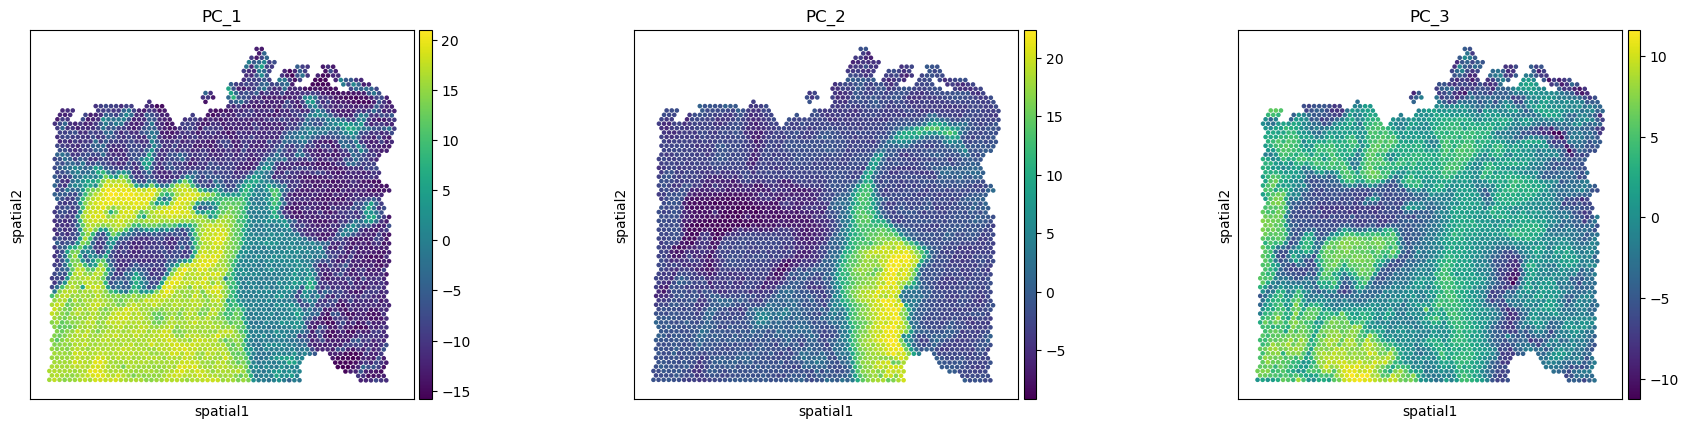

In [10]:
for i in range(3):
    adata_visium.obs[f'PC_{i+1}'] = adata_visium.obsm['X_pca'][:, i]

sc.pl.spatial(adata_visium, color=['PC_1', 'PC_2', 'PC_3'], img_key=None,size=1.5)

In [11]:
mdl = kernelRhoPCA(
    adata_visium, adata_chromium, 
    kernel = 'gaussian',
    kernel_kwargs = dict(bandwidth=50)
)

In [12]:
st_fit = time.time() 
mdl.fit(verbose=True, method='tikhonov') 

print(f"krhoPCA Runtime: {(time.time() - st_fit)/60} minutes")

----------------------------------------
Covariance: Computing target covariance (kernel='gaussian', {'bandwidth': 50})...
----------------------------------------
Covariance: Computing background covariance (no kernel)...
----------------------------------------
Covariance: Complete.
----------------------------------------
Eigendecomposition: Computing eigenvectors and eigenvalues...
----------------------------------------
Eigendecomposition: Complete.
----------------------------------------
Projecting: ...
----------------------------------------
: Finished computing projections.
krhoPCA Runtime: 0.5060534358024598 minutes


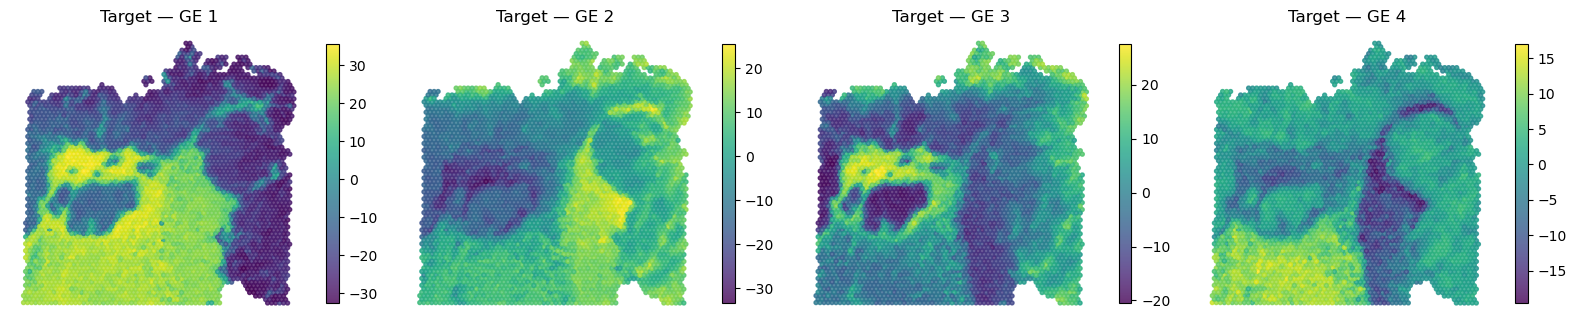

In [13]:
mdl.plot(components=(1,2,3,4), plot_type="spatial")

In [14]:
mdl.get_top_genes(component=1)

['ASCL2', 'EREG', 'ETV4', 'TRIM29', 'SFRP4']

## Analysis with Visium HD

In [15]:
sdata = visium_hd(
    vis_hd_path, 
    bin_size=8,
    load_segmentations_only=False
)   

sdata

/home/kayla-jackson/opt/anaconda3/envs/rhopca/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/tmp/ipykernel_2192846/724811602.py:1: UserWarning: No full resolution image found. If incorrect, please specify the path in the `fullres_image_file` parameter when calling the `visium_hd` reader function.
  sdata = visium_hd(


SpatialData object
├── Images
│     ├── 'Visium_HD_Human_Colon_Cancer_P2_hires_image': DataArray[cyx] (3, 3886, 6000)
│     └── 'Visium_HD_Human_Colon_Cancer_P2_lowres_image': DataArray[cyx] (3, 389, 600)
├── Shapes
│     └── 'Visium_HD_Human_Colon_Cancer_P2_square_008um': GeoDataFrame shape: (545913, 1) (2D shapes)
└── Tables
      └── 'square_008um': AnnData (545913, 18085)
with coordinate systems:
    ▸ 'Visium_HD_Human_Colon_Cancer_P2', with elements:
        Visium_HD_Human_Colon_Cancer_P2_hires_image (Images), Visium_HD_Human_Colon_Cancer_P2_lowres_image (Images), Visium_HD_Human_Colon_Cancer_P2_square_008um (Shapes)
    ▸ 'Visium_HD_Human_Colon_Cancer_P2_downscaled_hires', with elements:
        Visium_HD_Human_Colon_Cancer_P2_hires_image (Images), Visium_HD_Human_Colon_Cancer_P2_square_008um (Shapes)
    ▸ 'Visium_HD_Human_Colon_Cancer_P2_downscaled_lowres', with elements:
        Visium_HD_Human_Colon_Cancer_P2_lowres_image (Images), Visium_HD_Human_Colon_Cancer_P2_square_008u

In [16]:
adata_vhd = sdata.tables['square_008um']

In [17]:
adata_vhd = process_adata(
    adata_vhd,
    min_counts = np.expm1(4).astype("int"),
    max_counts = np.expm1(8).astype("int"),
    max_mt_pct = 100,
    target_sum=None
)

Before filtering, there are 545913 obs and 18085 vars
After filtering vars, there are 545913 obs and 16946 vars
After mt-filter, there are 545850 obs and 16946 vars
After filtering cells, there are 471258 obs and 16946 vars


In [18]:
adata_vhd = adata_vhd[:, genes_keep]

In [19]:
mdl = kernelRhoPCA(
    adata_vhd, 
    adata_chromium, 
    kernel = 'gaussian'
)

In [20]:
st_fit = time.time() 
mdl.fit(verbose=True, method='tikhonov') 
et_fit = time.time() 

print(f"krhoPCA Runtime (VisHD): {(time.time() - st_fit)/60} minutes")

----------------------------------------
Covariance: Computing target covariance (kernel='gaussian')...
----------------------------------------
Covariance: Computing background covariance (no kernel)...
----------------------------------------
Covariance: Complete.
----------------------------------------
Eigendecomposition: Computing eigenvectors and eigenvalues...
----------------------------------------
Eigendecomposition: Complete.
----------------------------------------
Projecting: ...
----------------------------------------
: Finished computing projections.
krhoPCA Runtime (VisHD): 10.288690956433614 minutes


In [21]:
sdata.tables['square_008um'] = adata_vhd

In [22]:
sdata.tables['square_008um'].obsm['X_krpca'] = mdl.target_proj
sdata.tables['square_008um'].obs['krpc0'] = mdl.target_proj[:,0]

/tmp/ipykernel_2192846/472074201.py:1: ImplicitModificationWarning: Setting element `.obsm['X_krpca']` of view, initializing view as actual.
  sdata.tables['square_008um'].obsm['X_krpca'] = mdl.target_proj


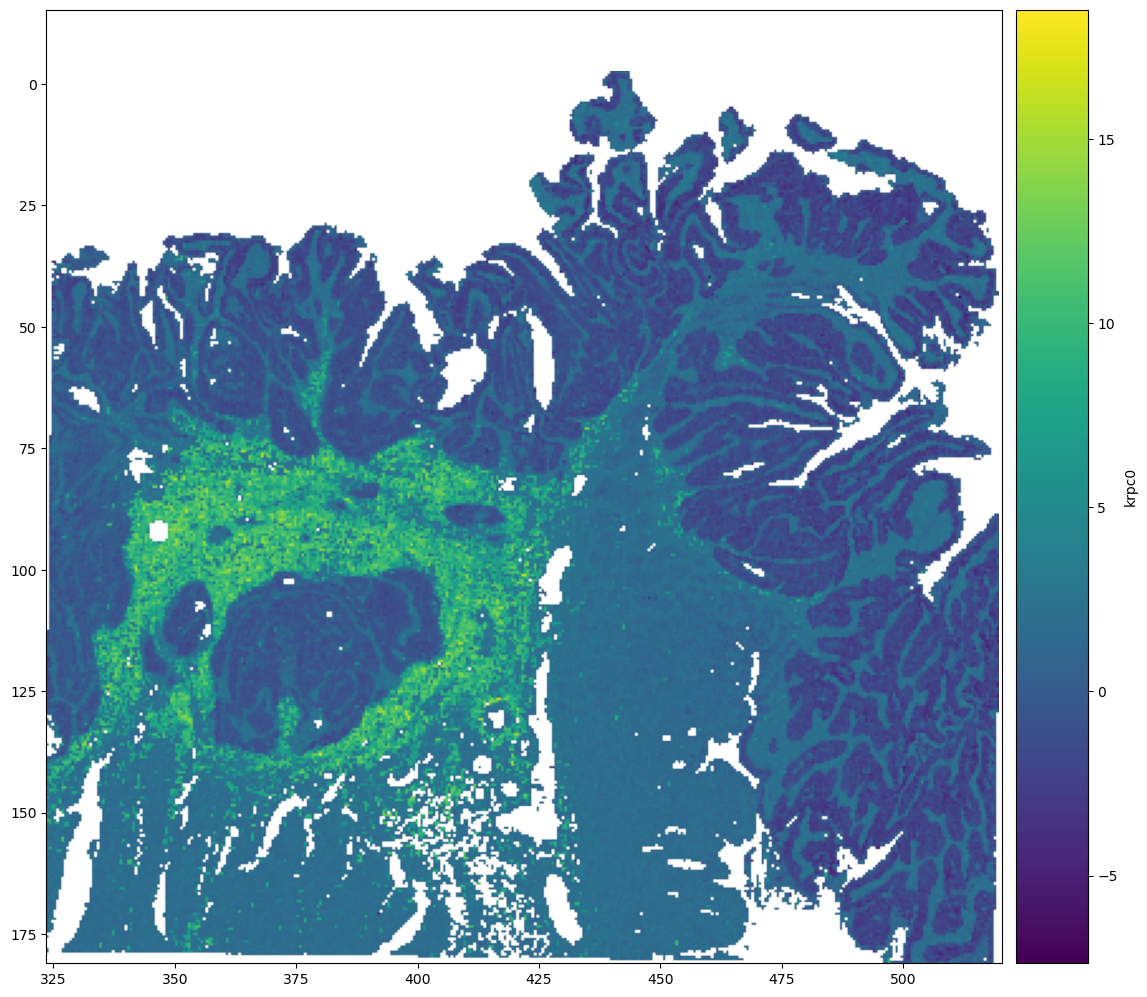

In [23]:
sdata.pl.render_shapes(
    "Visium_HD_Human_Colon_Cancer_P2_square_008um",
    color='krpc0', 
).pl.show(
    coordinate_systems="Visium_HD_Human_Colon_Cancer_P2_downscaled_lowres",
    figsize=(10,10),
    title=""
)

## Computing environment

In [24]:
session_info2.session_info()

/tmp/ipykernel_2192846/137287843.py:1: RuntimeWarning: Failed to import dependencies for application/vnd.jupyter.widget-view+json representation. (ModuleNotFoundError: No module named 'ipywidgets')
  session_info2.session_info()


Package,Version
spatialdata,0.7.2
rhopca,1.0.0
anndata,0.12.10
scanpy,1.12
spatialdata-plot,0.3.2
spatialdata-io,0.6.0
numpy,2.4.3
Component,Info
Python,"3.13.12 | packaged by conda-forge | (main, Feb 5 2026, 05:53:46) [GCC 14.3.0]"
OS,Linux-4.18.0-338.el8.x86_64-x86_64-with-glibc2.28
